Day 6

## Climate Change Dataset 1 Analysis

**Dataset Name:** Climate Change Dataset(linear regression)

### Objective

The objective of this notebook is to analyze the Climate Change dataset, understand the relationships between different features, preprocess the data, handle missing values, visualize the dataset using Seaborn, perform feature scaling and encoding, build a Linear Regression model, evaluate its performance, and save the trained model.

## Step 1: Import Required Libraries

In this step, we import all the required Python libraries for data analysis, data visualization, preprocessing, machine learning, model evaluation, and model saving.

These libraries help us to:
- Load and analyze the dataset.
- Visualize data using Matplotlib and Seaborn.
- Handle categorical and numerical features.
- Split the dataset into training and testing sets.
- Build a Linear Regression model.
- Evaluate the model performance.
- Save the trained model for future use.

In [1]:


# Import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import joblib

In [2]:
# Upload CSV file
from google.colab import files

uploaded = files.upload()

Saving climate_change_dataset.csv to climate_change_dataset.csv


## Step 2: Load the Dataset

In this step, we load the Climate Change dataset into a Pandas DataFrame. This allows us to analyze, clean, preprocess, and visualize the data efficiently.

In [5]:
# Load the Climate Change Dataset
df = pd.read_csv("climate_change_dataset.csv")
# Display first five rows
df.head()

,Year,Country,Avg Temperature (°C),CO2 Emissions (Tons/Capita),Sea Level Rise (mm),Rainfall (mm),Population,Renewable Energy (%),Extreme Weather Events,Forest Area (%)
0,2006,UK,8.9,9.3,3.1,1441,530911230,20.4,14,59.8
1,2019,USA,31.0,4.8,4.2,2407,107364344,49.2,8,31.0
2,2014,France,33.9,2.8,2.2,1241,441101758,33.3,9,35.5
3,2010,Argentina,5.9,1.8,3.2,1892,1069669579,23.7,7,17.7
4,2007,Germany,26.9,5.6,2.4,1743,124079175,12.5,4,17.4


In [6]:
# Display the last five rows

df.tail()


,Year,Country,Avg Temperature (°C),CO2 Emissions (Tons/Capita),Sea Level Rise (mm),Rainfall (mm),Population,Renewable Energy (%),Extreme Weather Events,Forest Area (%)
995,2019,India,23.6,8.0,1.2,1365,1358019778,10.0,8,20.2
996,2000,UK,21.8,10.0,2.2,1273,876123161,14.9,14,30.1
997,2019,Argentina,23.8,8.9,4.7,891,1120533308,25.9,10,46.5
998,2016,Australia,21.0,14.9,3.1,1136,380662109,24.5,3,44.5
999,2011,Germany,24.1,17.3,2.1,2854,398407112,41.0,3,19.8


In [7]:
# Display the shape of the dataset
df.shape

# Display all column names
df.columns

# Display dataset information
df.info()

# Generate statistical summary
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Year                         1000 non-null   int64  
 1   Country                      1000 non-null   object 
 2   Avg Temperature (°C)         1000 non-null   float64
 3   CO2 Emissions (Tons/Capita)  1000 non-null   float64
 4   Sea Level Rise (mm)          1000 non-null   float64
 5   Rainfall (mm)                1000 non-null   int64  
 6   Population                   1000 non-null   int64  
 7   Renewable Energy (%)         1000 non-null   float64
 8   Extreme Weather Events       1000 non-null   int64  
 9   Forest Area (%)              1000 non-null   float64
dtypes: float64(5), int64(4), object(1)
memory usage: 78.3+ KB


,Year,Avg Temperature (°C),CO2 Emissions (Tons/Capita),Sea Level Rise (mm),Rainfall (mm),Population,Renewable Energy (%),Extreme Weather Events,Forest Area (%)
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000
mean,2011.432000,19.883100,10.425800,3.009600,1738.761000,7.053830e+08,27.300500,7.291000,40.572000
std,7.147199,8.542897,5.614665,1.146081,708.976616,4.093910e+08,12.970808,4.422655,17.398998
min,2000.000000,5.000000,0.500000,1.000000,501.000000,3.660891e+06,5.100000,0.000000,10.100000
25%,2005.000000,12.175000,5.575000,2.000000,1098.750000,3.436242e+08,16.100000,3.000000,25.600000
50%,2012.000000,20.100000,10.700000,3.000000,1726.000000,7.131166e+08,27.150000,8.000000,41.150000
75%,2018.000000,27.225000,15.400000,4.000000,2362.500000,1.073868e+09,38.925000,11.000000,55.800000
max,2023.000000,34.900000,20.000000,5.000000,2999.000000,1.397016e+09,50.000000,14.000000,70.000000


In [10]:
# Display all column names
df.columns

Index(['Year', 'Country', 'Avg Temperature (°C)',
       'CO2 Emissions (Tons/Capita)', 'Sea Level Rise (mm)', 'Rainfall (mm)',
       'Population', 'Renewable Energy (%)', 'Extreme Weather Events',
       'Forest Area (%)'],
      dtype='object')

In [9]:
# Display the shape of the dataset
df.shape


(1000, 10)

In [11]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Year                         1000 non-null   int64  
 1   Country                      1000 non-null   object 
 2   Avg Temperature (°C)         1000 non-null   float64
 3   CO2 Emissions (Tons/Capita)  1000 non-null   float64
 4   Sea Level Rise (mm)          1000 non-null   float64
 5   Rainfall (mm)                1000 non-null   int64  
 6   Population                   1000 non-null   int64  
 7   Renewable Energy (%)         1000 non-null   float64
 8   Extreme Weather Events       1000 non-null   int64  
 9   Forest Area (%)              1000 non-null   float64
dtypes: float64(5), int64(4), object(1)
memory usage: 78.3+ KB


In [12]:
# Generate statistical summary
df.describe()

,Year,Avg Temperature (°C),CO2 Emissions (Tons/Capita),Sea Level Rise (mm),Rainfall (mm),Population,Renewable Energy (%),Extreme Weather Events,Forest Area (%)
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000
mean,2011.432000,19.883100,10.425800,3.009600,1738.761000,7.053830e+08,27.300500,7.291000,40.572000
std,7.147199,8.542897,5.614665,1.146081,708.976616,4.093910e+08,12.970808,4.422655,17.398998
min,2000.000000,5.000000,0.500000,1.000000,501.000000,3.660891e+06,5.100000,0.000000,10.100000
25%,2005.000000,12.175000,5.575000,2.000000,1098.750000,3.436242e+08,16.100000,3.000000,25.600000
50%,2012.000000,20.100000,10.700000,3.000000,1726.000000,7.131166e+08,27.150000,8.000000,41.150000
75%,2018.000000,27.225000,15.400000,4.000000,2362.500000,1.073868e+09,38.925000,11.000000,55.800000
max,2023.000000,34.900000,20.000000,5.000000,2999.000000,1.397016e+09,50.000000,14.000000,70.000000


In [13]:
# Check missing values

df.isnull().sum()

,0
Year,0
Country,0
Avg Temperature (°C),0
CO2 Emissions (Tons/Capita),0
Sea Level Rise (mm),0
Rainfall (mm),0
Population,0
Renewable Energy (%),0
Extreme Weather Events,0
Forest Area (%),0


In [14]:
# Fill missing values in numerical columns

df.fillna(df.mean(numeric_only=True), inplace=True)

# Fill missing values in categorical columns

for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

# Verify missing values

df.isnull().sum()

/tmp/ipykernel_1634/1383561490.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


,0
Year,0
Country,0
Avg Temperature (°C),0
CO2 Emissions (Tons/Capita),0
Sea Level Rise (mm),0
Rainfall (mm),0
Population,0
Renewable Energy (%),0
Extreme Weather Events,0
Forest Area (%),0


### Dataset Understanding

- The dataset contains information related to climate change and environmental factors.
- Each row represents climate information for a specific country and year.
- The dataset contains both numerical and categorical features.
- The **Country** column is categorical, while the remaining columns are numerical.
- This dataset can be used to analyze environmental trends and build a regression model for prediction.
- Missing values have been handled to improve data quality before model training.

In [15]:
# Check duplicate records

df.duplicated().sum()

np.int64(0)

In [16]:
# Remove duplicate records

df.drop_duplicates(inplace=True)

# Verify dataset shape after removing duplicates

df.shape

(1000, 10)

#Correlation Analysis

Correlation analysis helps us understand the relationship between numerical features.

- A value close to **1** indicates a strong positive relationship.
- A value close to **-1** indicates a strong negative relationship.
- A value close to **0** indicates little or no relationship.

This analysis helps us understand how one feature influences another.

In [17]:
# Display correlation matrix

df.corr(numeric_only=True)

,Year,Avg Temperature (°C),CO2 Emissions (Tons/Capita),Sea Level Rise (mm),Rainfall (mm),Population,Renewable Energy (%),Extreme Weather Events,Forest Area (%)
Year,1.000000,0.020954,0.041018,0.035433,-0.013638,0.071744,0.023826,-0.021620,-0.041327
Avg Temperature (°C),0.020954,1.000000,0.012323,0.059005,-0.004532,0.003550,-0.065472,0.034951,-0.017027
CO2 Emissions (Tons/Capita),0.041018,0.012323,1.000000,-0.038815,0.013306,0.011529,-0.023355,-0.004019,0.031387
Sea Level Rise (mm),0.035433,0.059005,-0.038815,1.000000,0.022104,-0.000277,0.003655,0.025003,-0.028670
Rainfall (mm),-0.013638,-0.004532,0.013306,0.022104,1.000000,0.009254,-0.005641,-0.006967,0.018571
Population,0.071744,0.003550,0.011529,-0.000277,0.009254,1.000000,0.001785,0.005175,-0.011638
Renewable Energy (%),0.023826,-0.065472,-0.023355,0.003655,-0.005641,0.001785,1.000000,0.000172,-0.021138
Extreme Weather Events,-0.021620,0.034951,-0.004019,0.025003,-0.006967,0.005175,0.000172,1.000000,-0.009291
Forest Area (%),-0.041327,-0.017027,0.031387,-0.028670,0.018571,-0.011638,-0.021138,-0.009291,1.000000


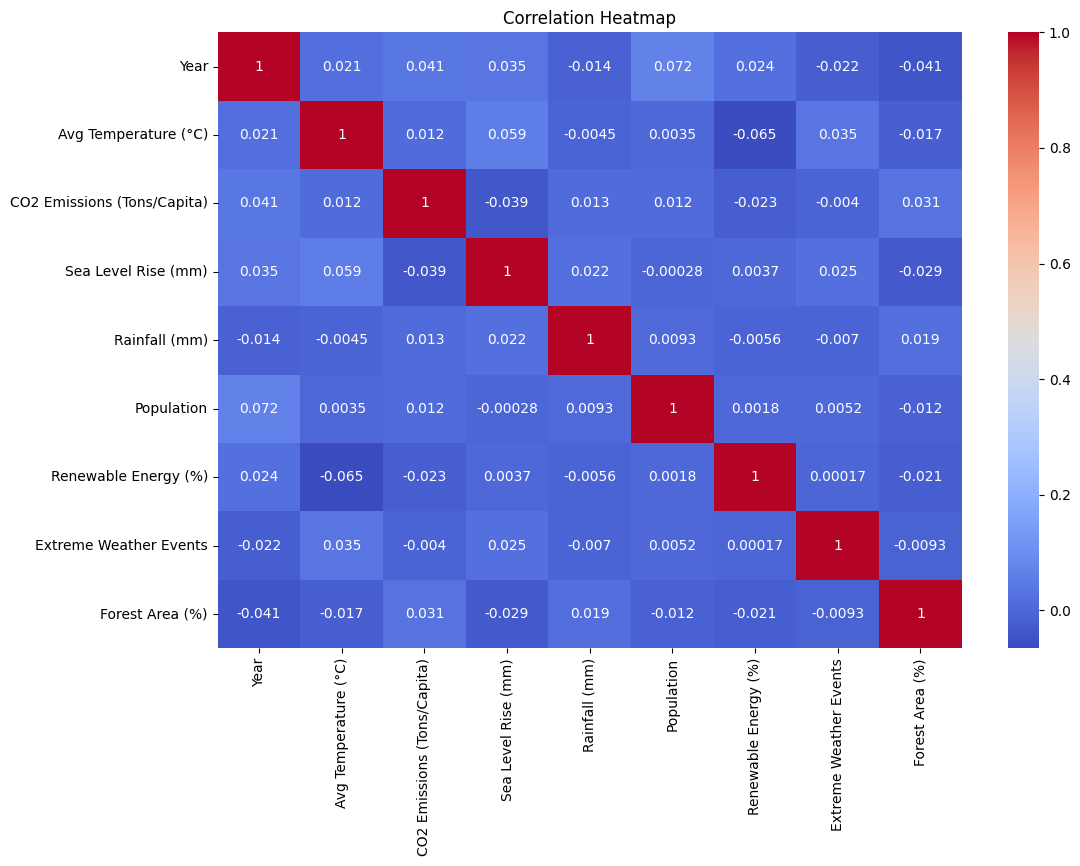

In [18]:
# Plot correlation heatmap

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

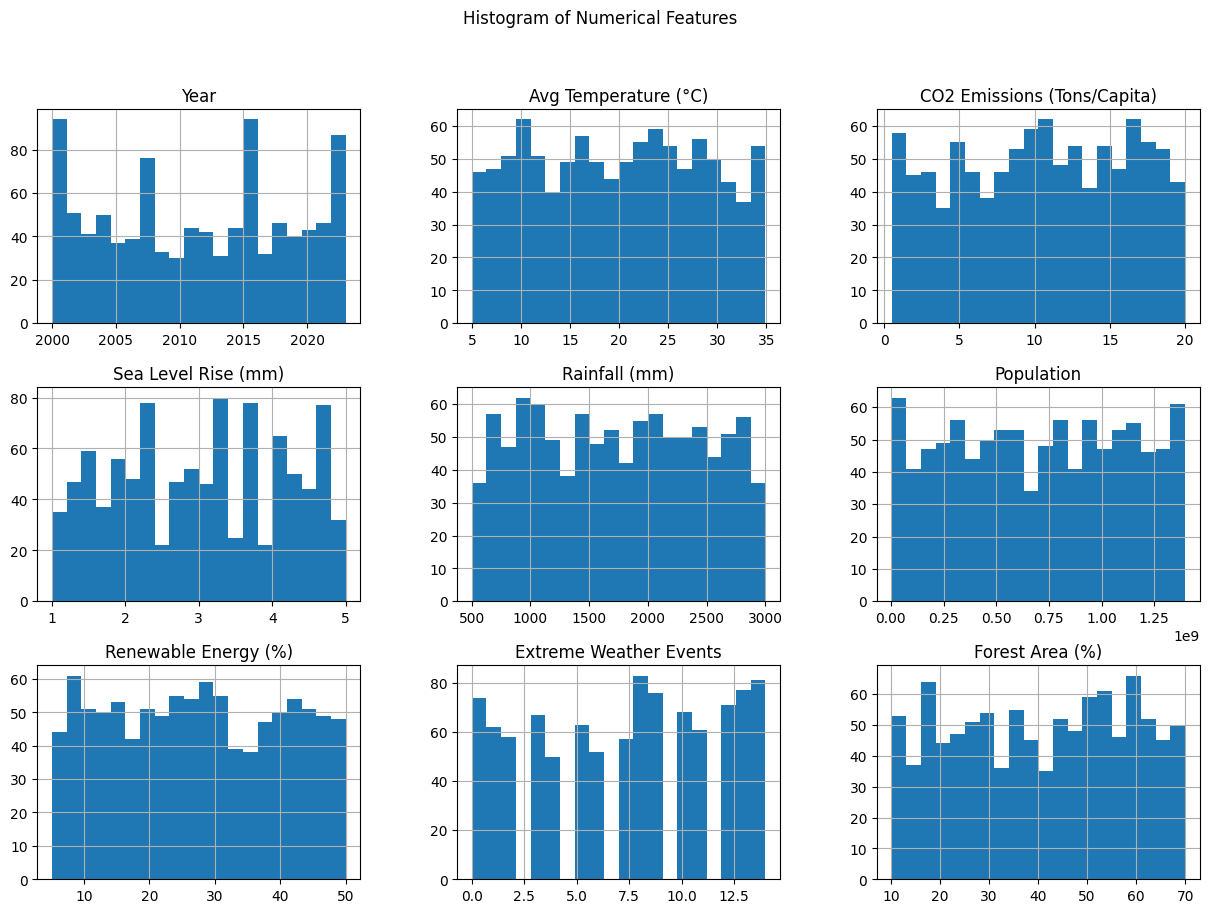

In [19]:
# Plot histograms for all numerical columns

df.hist(figsize=(15,10), bins=20)
plt.suptitle("Histogram of Numerical Features")
plt.show()



### Observation

- Most correlation values are close to **0**, indicating weak relationships between the features.
- There is no strong positive or negative correlation among the numerical variables.
- The dataset does not show multicollinearity issues.
- Each feature contributes independently to the dataset.
- Correlation analysis helps in understanding the relationship between different climate-related factors before building the machine learning model.

In [20]:
df.head()

,Year,Country,Avg Temperature (°C),CO2 Emissions (Tons/Capita),Sea Level Rise (mm),Rainfall (mm),Population,Renewable Energy (%),Extreme Weather Events,Forest Area (%)
0,2006,UK,8.9,9.3,3.1,1441,530911230,20.4,14,59.8
1,2019,USA,31.0,4.8,4.2,2407,107364344,49.2,8,31.0
2,2014,France,33.9,2.8,2.2,1241,441101758,33.3,9,35.5
3,2010,Argentina,5.9,1.8,3.2,1892,1069669579,23.7,7,17.7
4,2007,Germany,26.9,5.6,2.4,1743,124079175,12.5,4,17.4


In [33]:
# Convert categorical column using One-Hot Encoding

df = pd.get_dummies(df, columns=["Country"], drop_first=True)

# Display the updated dataset

df.head()

,Year,Avg Temperature (°C),CO2 Emissions (Tons/Capita),Sea Level Rise (mm),Rainfall (mm),Population,Renewable Energy (%),Extreme Weather Events,Forest Area (%),Country_-1.4135947330677938,...,Country_-0.48967660687969333,Country_-0.25869707533266817,Country_-0.02771754378564304,Country_0.2032619877613821,Country_0.43424151930840726,Country_0.6652210508554324,Country_0.8962005824024575,Country_1.1271801139494826,Country_1.3581596454965077,Country_1.589139177043533
0,-0.760398,-1.286284,-0.200611,0.078917,-0.420197,-0.426387,-0.532269,1.517721,1.105674,False,...,False,False,False,False,False,False,False,False,True,False
1,1.059406,1.301954,-1.002485,1.039190,0.943012,-1.461483,1.689213,0.160391,-0.550422,False,...,False,False,False,False,False,False,False,False,False,True
2,0.359481,1.641588,-1.358873,-0.706761,-0.702435,-0.645870,0.462770,0.386613,-0.291657,False,...,True,False,False,False,False,False,False,False,False,False
3,-0.200458,-1.637629,-1.537067,0.166215,0.216249,0.890271,-0.277724,-0.065831,-1.315216,False,...,False,False,False,False,False,False,False,False,False,False
4,-0.620413,0.821783,-0.859929,-0.532166,0.005982,-1.420634,-1.141633,-0.744495,-1.332467,False,...,False,True,False,False,False,False,False,False,False,False


In [21]:
# Apply Label Encoding to categorical columns

le = LabelEncoder()

df["Country"] = le.fit_transform(df["Country"])

df.head()

,Year,Country,Avg Temperature (°C),CO2 Emissions (Tons/Capita),Sea Level Rise (mm),Rainfall (mm),Population,Renewable Energy (%),Extreme Weather Events,Forest Area (%)
0,2006,13,8.9,9.3,3.1,1441,530911230,20.4,14,59.8
1,2019,14,31.0,4.8,4.2,2407,107364344,49.2,8,31.0
2,2014,5,33.9,2.8,2.2,1241,441101758,33.3,9,35.5
3,2010,0,5.9,1.8,3.2,1892,1069669579,23.7,7,17.7
4,2007,6,26.9,5.6,2.4,1743,124079175,12.5,4,17.4


In [22]:
# Scale numerical columns

scaler = StandardScaler()

num_cols = df.select_dtypes(include=np.number).columns

df[num_cols] = scaler.fit_transform(df[num_cols])

df.head()

,Year,Country,Avg Temperature (°C),CO2 Emissions (Tons/Capita),Sea Level Rise (mm),Rainfall (mm),Population,Renewable Energy (%),Extreme Weather Events,Forest Area (%)
0,-0.760398,1.358160,-1.286284,-0.200611,0.078917,-0.420197,-0.426387,-0.532269,1.517721,1.105674
1,1.059406,1.589139,1.301954,-1.002485,1.039190,0.943012,-1.461483,1.689213,0.160391,-0.550422
2,0.359481,-0.489677,1.641588,-1.358873,-0.706761,-0.702435,-0.645870,0.462770,0.386613,-0.291657
3,-0.200458,-1.644574,-1.637629,-1.537067,0.166215,0.216249,0.890271,-0.277724,-0.065831,-1.315216
4,-0.620413,-0.258697,0.821783,-0.859929,-0.532166,0.005982,-1.420634,-1.141633,-0.744495,-1.332467


##  Select Features and Target Variable

In this step, we separate the dataset into:

- **Features (X):** Independent variables used for prediction.
- **Target (y):** Dependent variable to be predicted.

Here, **Average Temperature (°C)** is selected as the target variable because it is a continuous numerical value suitable for Linear Regression.

In [23]:
# Select Features (X) and Target Variable (y)

X = df.drop("Avg Temperature (°C)", axis=1)

y = df["Avg Temperature (°C)"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (1000, 9)
Target Shape: (1000,)


##  Split the Dataset

The dataset is divided into:

- **80% Training Data**
- **20% Testing Data**

The training data is used to train the model, while the testing data is used to evaluate its performance.

In [26]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

##  Build the Linear Regression Model

Linear Regression is used because the target variable is continuous.

The model learns the relationship between the independent variables and the target variable.

In [28]:
# Create and train the Linear Regression model

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [29]:
# Predict on the test data

y_pred = model.predict(X_test)

y_pred[:10]

array([-0.01156963, -0.00923754, -0.1203287 , -0.05576071,  0.01622156,
        0.07969438, -0.07011442,  0.10583947, -0.11505702,  0.0468487 ])

##  Evaluate the Linear Regression Model

The performance of the Linear Regression model is evaluated using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- R² Score

These metrics help us understand how accurately the model predicts the target variable.

In [30]:
# Evaluate the Linear Regression Model

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R2 Score:", r2)

Mean Absolute Error (MAE): 0.8278406764076833
Mean Squared Error (MSE): 0.9483917542251448
R2 Score: 0.00197451356846301


##  Model Performance Insights

### Insights

- **Mean Absolute Error (MAE):** Measures the average prediction error. Lower MAE indicates better model performance.

- **Mean Squared Error (MSE):** Measures the average squared prediction error. Lower MSE means the model predictions are closer to the actual values.

- **R² Score:** Indicates how well the model explains the variation in the target variable.
  - R² close to **1** → Excellent model
  - R² close to **0** → Weak model
  - R² below **0** → Poor model

These evaluation metrics help us determine the effectiveness of the Linear Regression model.

In [31]:
# Compare Actual and Predicted Values

results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
521,-0.056578,-0.011570
737,-0.688999,-0.009238
740,0.001979,-0.120329
660,-1.368265,-0.055761
411,1.149705,0.016222
678,0.411881,0.079694
626,-0.782690,-0.070114
513,0.564131,0.105839
859,0.224498,-0.115057
136,0.388458,0.046849


In [32]:
# Save the trained model

joblib.dump(model, "2026-07-11_linear_regression.pkl")

print("Model saved successfully!")

Model saved successfully!


# Final Conclusion

- Imported the Climate Change dataset.
- Explored and understood the dataset structure.
- Checked and handled missing values.
- Removed duplicate records.
- Performed correlation analysis.
- Visualized the dataset using Seaborn.
- Applied Label Encoding to categorical data.
- Applied Standard Scaling to numerical features.
- Split the dataset into training and testing sets.
- Built a Linear Regression model.
- Evaluated the model using MAE, MSE, and R² Score.
- Saved the trained model successfully.

This completes the Regression task for the Climate Change dataset.